# Изучение рынка заведений общественного питания Москвы

### Цели и задачи проекта

**Цель:** Провести исследовательский анализ данных рынка заведений общественного питания Москвы с целью подбора подходящего места для инвесторов фонда "Shut Up and Take My Money"

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - изучить данные более детально;
    - изучить самые популярные заведения на рынке и определить причины их успеха.
4. Сформулировать выводы по проведённому анализу.

### Описание данных

Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:
- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — `5.0`);
- `chain` — число, выраженное `0` или `1`, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки): 
    - `0` — заведение не является сетевым;
    - `1` — заведение является сетевым.
- `seats` — количество посадочных мест.
Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:
- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — хранит среднюю стоимость заказа в виде диапазона, например: 
    - «Средний счёт: 1000–1500 ₽»;
    - «Цена чашки капучино: 130–220 ₽»;
    - «Цена бокала пива: 400–600 ₽» и так далее;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»: 
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино»: 
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

### Содержимое проекта

1. Загрузка данных и знакомство с ними 
2. Предобработка данных 
3. Исследовательский анализ данных
4. Итоговый вывод и рекомендации

---

## 1. Загрузка данных и знакомство с ними

*Загрузите данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.*

In [1]:
# Импортируем все необходимые библиотеки
import pandas as pd 
# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns
# Устанавливаем и загружаем библиотеку для расчёта коэффициента корреляции phi_k
!pip install phik -q
from phik import phik_matrix

Данные будут сохранены в две переменные `info_df` и `price_df`.

In [2]:
info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

*Познакомьтесь с данными и изучите общую информацию о них.*

Изучаем информацию о датафрейме `info_df`.

In [3]:
# Выводим первые строки датафрейма info_df
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Выводим информацию о датафрейме info_df
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Изучаем информацию о датафрейме `price_df`.

In [5]:
# Выводим первые строки датафрейма price_df
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
# Выводим информацию о датафрейме price_df
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

Датафрейм `info_df` содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания.

После первичного просмотра данных в датафреме можно сделать следующие выводы: 
- Названия столбцов соответствуют привычному стилю `snake case`. Сами данные соответствуют названию и описанию. 
- Столбец `chain` можно привести к типу `bool`, так как в нем встречаются только значения `0` и `1`. Но и `int` также подходит.
- Столбец `seats` представлен типом данных `float`, так как в нем содержатся пустые значения, хотя можно данный столбец преобразовать в тип `int`. 
- По представленной информации по датафрейму видно, что пропуски содержатся в столбцах `hours` и `seats`, однако следует проверить в столбцах значения-индикаторы, которые могут говорить об отсутствии данных. 

Датафрейм `price_df` содержит 5 столбцов и 4058 строк, в которых представлена информация о среднем чеке в заведениях общественного питания.

После первичного просмотра данных в датафреме можно сделать следующие выводы: 
- Названия столбцов соответствуют привычному стилю `snake case`. Сами данные соответствуют названию и описанию. 
- Типы данных соответствуют описанию данных. 
- Пропуски содержатся во всех столбцах, кроме `id`.

---

### Подготовка единого датафрейма

*Объедините данные двух датасетов в один, с которым вы и продолжите работу.*

In [7]:
# Объединим два датафрейма info_df и price_df и выведем первые 5 строк получившегося датафрейма df
df = info_df.merge(price_df, on = 'id', how = 'left')
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [8]:
# Выведем информацию по созданному датафрейму
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


---

## 2. Предобработка данных

*Подготовьте данные к исследовательскому анализу:*

*Изучите корректность типов данных и при необходимости проведите их преобразование.*

**Нет необходимости преобразовывать типы данных, так как они соответствуют описанию.**

---

*Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.*

In [9]:
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [10]:
# Подсчитываем долю строк с пропусками
df.isna().sum() / df.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

In [11]:
# Доля пропущенных значений (версия 2)
df.isna().mean()

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

В датафрейме `df` можно увидеть пропуски в столбцах `hours`, `seats`, `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`. Причем в столбцах `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup` содержится больше половины пропусков от всего объема датафрейма. Показатели в разных заведениях одной сети могут отличаться, поэтому лучше оставить все пропуски без изменений, иначе можем исказить результаты исследовательского анализа.  

Далее проверим, встречаются ли в данных значения-индикаторы, которые можно рассматривать как пропуски. Посмотрим на уникальные значения в столбцах `district` и `category`.

In [12]:
# Проверяем уникальные значения в столбцах 
for column in ['district', 'category']:
    print(f'Уникальные значения в столбце {column}')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце district
['Восточный административный округ' 'Западный административный округ'
 'Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Центральный административный округ'
 'Юго-Восточный административный округ'
 'Юго-Западный административный округ' 'Южный административный округ']

Уникальные значения в столбце category
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']



Все значения выглядят корректными. Теперь можно перейти к изучению дубликатов в данных.

---

*Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.*

In [13]:
# Проверяем полные дубликаты в датафрейме df
df.duplicated().sum()

0

В объединенном датафрейме отсутствуют полные дубликаты строк. 

Нормализуем данные в столбцах `name` и `address` приведя их к единому регистру

In [14]:
df['name'] = df['name'].str.lower()
df['address'] = df['address'].str.lower()

In [15]:
# Выведем неявные дубликаты в датафрейме df по названию и адресу заведения 
dupl_name_address = df[df.duplicated(subset = ['name', 'address'], keep = False)].sort_values('address')
dupl_name_address

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188.0,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,0,NaN,NaN,NaN,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,NaN,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,NaN,NaN,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276.0,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,NaN,4.1,0,276.0,NaN,NaN,NaN,NaN


Ввиду того, что многие столбцы содержат высокий процент пропусков, их обработка могла бы внести существенную ошибку в дальнейший анализ. На основании этого принято решение отказаться от очистки данных пропусков и оставить данные неизменными.

*Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:*
- *логическое значение `True` — если заведение работает ежедневно и круглосуточно;*
- *логическое значение `False` — в противоположном случае.*

Для начала посмотрим, какие уникальные значения содержатся в столбце `hours`, чтобы понять, как идентицифировать работу заведений.

In [16]:
df['hours'].unique()

array(['ежедневно, 10:00–22:00',
       'пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00',
       'ежедневно, 09:00–22:00', ...,
       'пн-пт 08:30–21:30; сб,вс 09:00–21:30',
       'пн-чт 13:00–22:00; пт,сб 13:00–22:30; вс 13:00–22:00',
       'пн-сб 10:30–21:30'], dtype=object)

In [17]:
# Добавляем столбец is_24_7 с определением работы заведений
df['is_24_7'] = df['hours'].str.contains('ежедневно, круглосуточно', case = False, na = False)

In [18]:
# Выведем количество значений в столбце is_24_7
df['is_24_7'].value_counts()

False    7676
True      730
Name: is_24_7, dtype: int64

---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

Выводы по предобработке: 
- Типы данных не преобразовывали, так как они изначально были корректными. 
- В датафрейме содержится большое количество пропусков в столбцах `hours`, `seats`, `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`. Показатели в разных заведениях одной сети могут отличаться, поэтому лучше оставить все пропуски без изменений, иначе можем исказить результаты исследовательского анализа. 
- В объединенном датафрейме отсутствуют явные дубликаты, но есть дубликаты по названию и адресу заведений, которые было принято оставить. Стоит отметить, что все значения `id` в неявных дубликатах разные, поэтому данные строки, возможно, не являются вообще дубликатами.   
- Был создан столбец `is_24_7` с обозначением того, работает ли заведение ежедневно и круглосуточно или нет.

## 3. Исследовательский анализ данных
*Проведите исследовательский анализ исходных данных.*

*При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.*

*После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.*

---

### Задача 1

*Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.*

In [19]:
# Выведем категории заведений, а также их количество в датафрейме df
df['category'].value_counts()

кафе               2378
ресторан           2043
кофейня            1413
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

In [20]:
# Доли категорий заведений
df['category'].value_counts(normalize = True)

кафе               0.282893
ресторан           0.243041
кофейня            0.168094
бар,паб            0.091006
пиццерия           0.075303
быстрое питание    0.071734
столовая           0.037473
булочная           0.030454
Name: category, dtype: float64

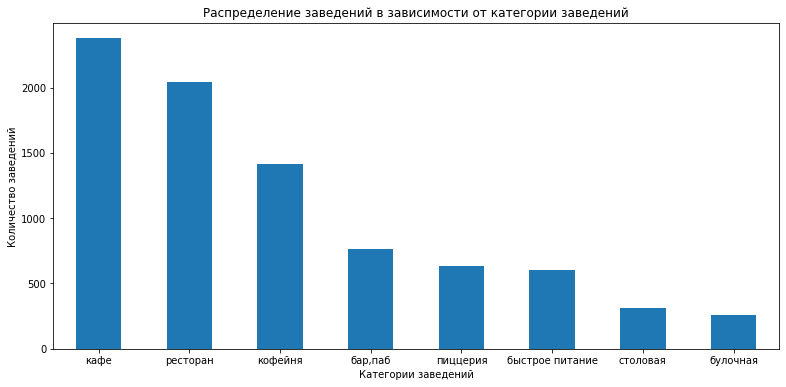

In [21]:
# Построим диаграмму распределения категорий заведений
plt.figure(figsize = (13, 6))
df['category'].value_counts().plot(
    kind = 'bar', # Столбчатая диаграмма
    rot = 0, # Градус вращения подписей
    legend = False, # Отключаем легенду
    title = 'Распределение заведений в зависимости от категории заведений'
)
plt.xlabel('Категории заведений')
plt.ylabel('Количество заведений')
plt.show()

**Выводы:** В датафрейме содержится 8 категорий заведений. При этом преобладают кафе (28,29% от всего количества) и рестораны (24,30% от всего количества), их больше 2000. Также видим, что в датафрейме содержится достаточно большое количество кофеен (1413 заведений, что составляет 16,81%). Также видим, что меньше всего в Москве столовых (3,75%) и булочных (3,05%). 

---

### Задача 2

*Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.*

In [22]:
# Выведем административные районы Москвы заведений, а также их количество в датафрейме df
df['district'].value_counts()

Центральный административный округ         2242
Северный административный округ             900
Южный административный округ                892
Северо-Восточный административный округ     891
Западный административный округ             851
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

In [23]:
# Доли административных районов Москвы заведений
df['district'].value_counts(normalize = True)

Центральный административный округ         0.266714
Северный административный округ            0.107066
Южный административный округ               0.106115
Северо-Восточный административный округ    0.105996
Западный административный округ            0.101237
Восточный административный округ           0.094932
Юго-Восточный административный округ       0.084939
Юго-Западный административный округ        0.084345
Северо-Западный административный округ     0.048656
Name: district, dtype: float64

In [24]:
# Распределение заведений каждой категории в Центральном административном округе Москвы
df[df['district'] == 'Центральный административный округ']['category'].value_counts()

ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

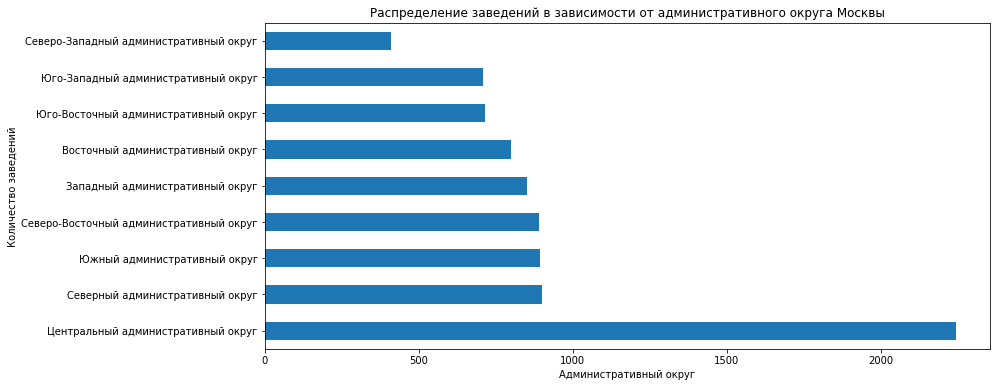

In [25]:
# Диаграмма распределения заведений по округам (для наглядности сделаем его горизонтальным)
plt.figure(figsize = (13, 6))
df['district'].value_counts().plot(
    kind = 'barh', # Столбчатая диаграмма
    rot = 0, # Градус вращения подписей
    legend = False, # Отключаем легенду
    title = 'Распределение заведений в зависимости от административного округа Москвы'
)
plt.xlabel('Административный округ')
plt.ylabel('Количество заведений')
plt.show()

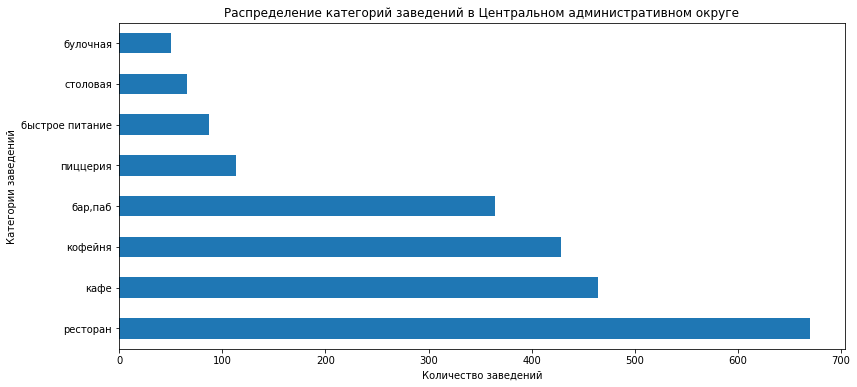

In [26]:
# Диаграмма распределения заведений по категориям в Центральном административном округе
plt.figure(figsize = (13, 6))
df[df['district'] == 'Центральный административный округ']['category'].value_counts().plot(
    kind = 'barh', # Столбчатая диаграмма
    rot = 0, # Градус вращения подписей
    legend = False, # Отключаем легенду
    title = 'Распределение категорий заведений в Центральном административном округе'
)
plt.xlabel('Количество заведений')
plt.ylabel('Категории заведений')
plt.show()

**Выводы:** Наибольшее количество заведений сосредоточено в Центральном административном округе - 2242 заведения (26,67% заведений). А наименьшее количество заведений приходится на Северо-западный административный округ - 409 заведений.  (4,87%). Рассматривая распределение категорий в Центральном административном округе, можно выделить, что в данном округе большая концентрация ресторанов (670 заведений), а вот меньше всего булочных (50 заведений).

---

### Задача 3

*Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.*

In [27]:
# Рассмотрим количество сетевых и несетевых заведений 
df['chain'].value_counts()

0    5201
1    3205
Name: chain, dtype: int64

In [28]:
# Посмотрим распределение сетевых и несетевых заведений в разрезе категорий
df.groupby(['category', 'chain'])['id'].count()

category         chain
бар,паб          0         596
                 1         169
булочная         0          99
                 1         157
быстрое питание  0         371
                 1         232
кафе             0        1599
                 1         779
кофейня          0         693
                 1         720
пиццерия         0         303
                 1         330
ресторан         0        1313
                 1         730
столовая         0         227
                 1          88
Name: id, dtype: int64

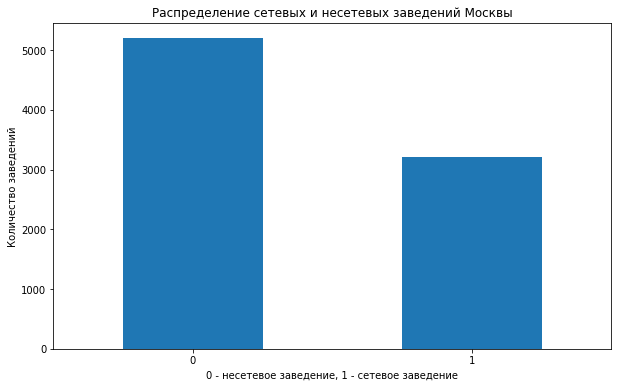

In [29]:
# Диаграмма распределения сетевых и несетевых заведений 
plt.figure(figsize = (10, 6))
df['chain'].value_counts().plot(
    kind = 'bar', # Столбчатая диаграмма
    rot = 0, # Градус вращения подписей
    legend = False, # Отключаем легенду
    title = 'Распределение сетевых и несетевых заведений Москвы'
)
plt.xlabel('0 - несетевое заведение, 1 - сетевое заведение')
plt.ylabel('Количество заведений')
plt.show()

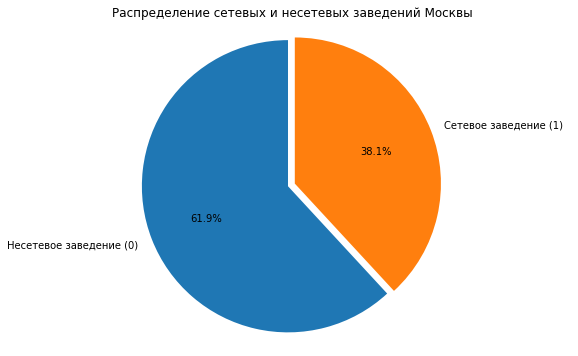

In [30]:
# Круговая диаграмма распределения сетевых и несетевых заведений 
plt.figure(figsize = (10, 6))
plt.pie(
    df['chain'].value_counts(), 
    labels = ['Несетевое заведение (0)', 'Сетевое заведение (1)'],
    autopct = '%1.1f%%', # Отображение процентов с 1 знаком после запятой
    startangle = 90, # Начальный угол поворота
    explode = (0.05, 0) # Небольшой вынос первого сектора (несетевых)
)
plt.title('Распределение сетевых и несетевых заведений Москвы')
plt.axis('equal') 
plt.show()

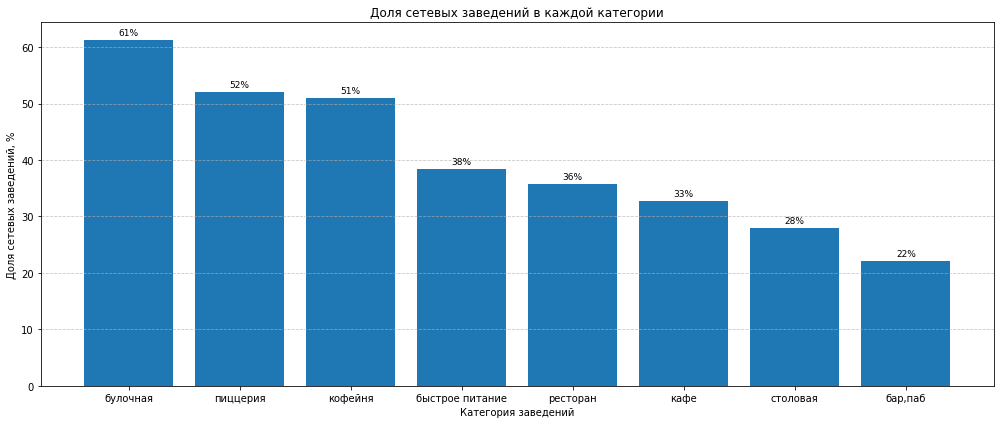

In [31]:
# Группируем по категории и считаем общее количество заведений и число сетевых заведений
category_stats = df.groupby('category')['chain'].agg(
    total = 'count',
    chain_sum = 'sum'  # Так как chain = 1 для сетевых, sum = кол-во сетевых
)
# Считаем долю сетевых
category_stats['share_chain'] = category_stats['chain_sum'] / category_stats['total']
# Сортируем по убыванию доли
category_stats = category_stats.sort_values('share_chain', ascending = False)
# Строим диаграмму долей (в процентах)
plt.figure(figsize = (14, 6))
bars = plt.bar(
    category_stats.index,
    category_stats['share_chain'] * 100  # переводим в проценты
)
# Добавим подписи процентов над столбцами
for bar, share in zip(bars, category_stats['share_chain']):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{share:.0%}',
        ha = 'center', va = 'bottom', fontsize = 9
    )
plt.title('Доля сетевых заведений в каждой категории')
plt.xlabel('Категория заведений')
plt.ylabel('Доля сетевых заведений, %')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

**Выводы:** Количество несетвых заведений превышает количество сетевых заведений. В сетевых заведениях преобладают такие категории как кафе, кофейня и ресторан. А в несетевых заведениях - кафе и ресторан. Стоит отметить, что количество сетевых заведений преобладает над несетевыми заведениями в категориях булочная, кофейня и пиццерия. 

---

### Задача 4

*Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.*


In [32]:
# Рассмотрим статистику по столбцу seats 
df['seats'].describe()

count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

In [33]:
# Посмотрим среднее количество посадочных мест в каждой из категорий
df.groupby('category')['seats'].mean().sort_values(ascending = False)

category
бар,паб            124.532051
ресторан           121.944094
кофейня            111.199734
столовая            99.750000
быстрое питание     98.891117
кафе                97.512315
пиццерия            94.496487
булочная            89.385135
Name: seats, dtype: float64

In [34]:
# Посмотрим медианное количество посадочных мест в каждой из категорий
df.groupby('category')['seats'].median().sort_values(ascending = False)

category
ресторан           86.0
бар,паб            82.5
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float64

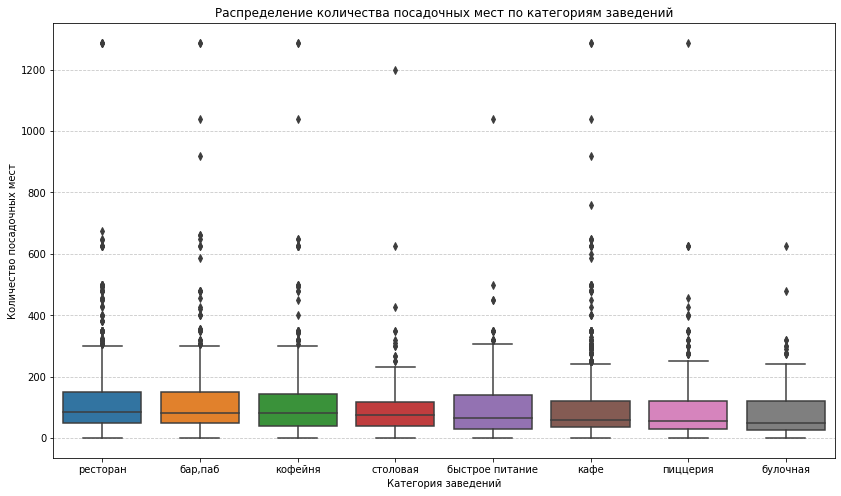

In [35]:
# Считаем медианы и сортируем категории по убыванию медианы
median_order = df.groupby('category')['seats'].median().sort_values(ascending = False).index
# Строим boxplot с явным указанием порядка категорий
plt.figure(figsize = (14, 8))
sns.boxplot(
    data = df,
    x = 'category',
    y = 'seats',
    order = median_order  # Cортировка по медиане
)
plt.title('Распределение количества посадочных мест по категориям заведений')
plt.xlabel('Категория заведений')
plt.ylabel('Количество посадочных мест')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.show()

**Выводы:** В выборке по количеству посадочных мест присутствует аномально большое значение, равное 1288 мест, а также можем увидеть и аномально маленькое значение - 0 мест. При этом среднее значение составляет примерно 108 мест (108.421689), а медианное значение равно 75. Аномально высокое значение количества посадочных мест могло возникнуть из-за некорректного подсчет, ведь заведение может находиться на фудкорте в торговом центре, поэтому в расчет количества в этом случае могут браться все места фудкорта. А аномально маленькое значение могло возникнуть из-за того, что данную информацию могли не ввести вовсе, либо заведение - это фудтрак на улице, который не предусматривает наличие посадочных мест, так как еда там готовится на вынос. Среднее арифметическое является достаточно завышенным, так как оно имеет достаточно большое отличие с медианным значением, а сама выборка при этом имеет выбросы. 

Если рассматривать диаграмму распределения количества посадочных мест, то можно увидеть большое количество выбросов по каждой категории заведений, поэтому и среднее арифметичское для таких данных нельзя рассматривать как показатель. Если рассматривать медианное распределение количества посадочных мест по категориям заведений, то можно заметить, что в ресторанах, барах и кофейнях медианное значение количества посадочных мест больше 80. Но в целом по выборке данное значение варьируется от 50 до 86 посадочных мест.

---

### Задача 5

*Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?*

In [36]:
# Средний рейтинг заведений в разрезе категорий заведений 
df.groupby('category')['rating'].mean().sort_values(ascending = False)

category
бар,паб            4.387712
пиццерия           4.301264
ресторан           4.290357
кофейня            4.277282
булочная           4.268359
столовая           4.211429
кафе               4.123886
быстрое питание    4.050249
Name: rating, dtype: float64

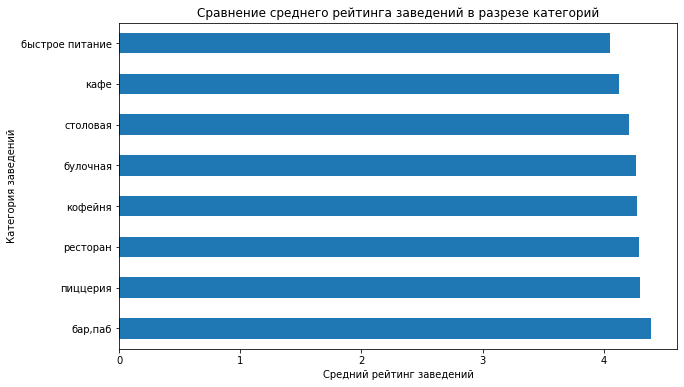

In [37]:
# Диаграмма сравнения среднего рейтинга заведений в разрезе категорий
plt.figure(figsize = (10, 6))
df.groupby('category')['rating'].mean().sort_values(ascending = False).plot(
    kind = 'barh', # Столбчатая диаграмма
    rot = 0, # Градус вращения подписей
    legend = False, # Отключаем легенду
    title = 'Сравнение среднего рейтинга заведений в разрезе категорий'
)
plt.xlabel('Средний рейтинг заведений')
plt.ylabel('Категория заведений')
plt.show()

**Выводы:** В целом, усредненный рейтинг заведений общепита находится практически на одном уровне, по 5-балльной шкале все заведения имеют средний рейтинг выше 4. А самый максимальный рейтинг при этом равен 4,38. Поэтому можно сказать, что средняя оценка заведений для каждой категории находится на одном уровне и не зависит от самой категории. 

---

### Задача 6

*Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.*

In [38]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df[['category', 'district', 'chain', 'seats', 'price', 'is_24_7', 'rating']].phik_matrix()
# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by = 'rating', ascending = False)

interval columns not set, guessing: ['chain', 'seats', 'rating']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.220295
district,0.200691
category,0.190003
is_24_7,0.150173
chain,0.108092
seats,0.000000


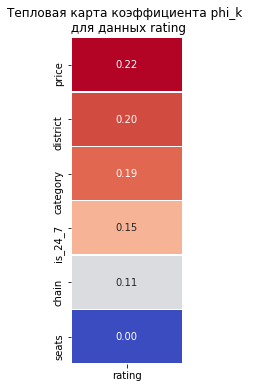

In [39]:
# Строим тепловую карту
plt.figure(figsize = (2, 6))
# Сохраняем матрицу корреляции признака churn с другими признаками клиента 
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by = 'rating', ascending = False)
sns.heatmap(
    data_heatmap,
    annot = True, # Отображаем численные значения в ячейках карты
    fmt = '.2f', # Форматируем значения корреляции: два знака после точки
    cmap = 'coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
    linewidths = 0.5, # Форматируем линию между ячейками карты
    cbar = False # Отключаем цветовую шкалу
)
# Добавляем заголовоу и подпись по оси X 
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
# Выводим график
plt.show()

Изучим зависимость между средним рейтингом заведения и ценовой категорией.

In [40]:
# Посмотрим распределение среднего рейтинга в разрезе категорий цен
df.groupby('price')['rating'].mean().sort_values(ascending = False)

price
высокие          4.436611
выше среднего    4.386348
средние          4.297874
низкие           4.173077
Name: rating, dtype: float64

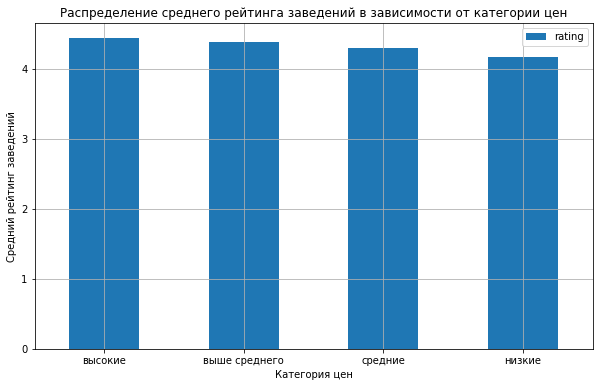

In [41]:
# Построим график столбчатой диаграммы
df.groupby('price')['rating'].mean().sort_values(ascending = False).plot(
    kind = 'bar',
    title = 'Распределение среднего рейтинга заведений в зависимости от категории цен',
    legend = True, 
    ylabel = 'Средний рейтинг заведений',
    xlabel = 'Категория цен',
    rot = 0,
    figsize = (10, 6)
)
plt.grid()
# Выводим график
plt.show()

**Выводы:** 
- Наибольшая корреляция рейтинга заведений наблюдается с категорией цен в заведении (`0.22`) и положением (`0.20`), но данные значения не показывают сильную корреляционную зависимость. Для остальных признаков коэффициент корреляции снижается с `0.19` до `0`.
- Стоит сразу отметить, что средний рейтинг изначально был больше 4 баллов по всей выборке, поэтому сильной разницы в нем мы можем не заметить. Но прослеживается положительная корреляционная связь: чем выше категория цен, тем выше средний рейтинг. Вероятнее всего, это связано с тем, что клиенты больше ценят высокое качество блюд, обслуживание и атмосферу, которые могут предложить заведения высокого ценового сегмента.

---

### Задача 7

*Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.*

In [42]:
# Оставим только те заведения, которые являются сетевыми
df_chain = df[df['chain'] == 1]
# Произведем группировку по названию и категории заведения и найдем количество заведений и средний рейтинг
df_chain_grouped = df_chain.groupby(['name', 'category']) \
    .agg({'id': 'count', 'rating': 'mean'}) \
    .sort_values('id', ascending = False).head(15)
df_chain_grouped

,,id,rating
name,category,,
шоколадница,кофейня,119,4.178151
домино'с пицца,пиццерия,76,4.169737
додо пицца,пиццерия,74,4.286486
one price coffee,кофейня,71,4.064789
яндекс лавка,ресторан,69,3.872464
cofix,кофейня,65,4.075385
prime,ресторан,49,4.114286
кофепорт,кофейня,42,4.147619
кулинарная лавка братьев караваевых,кафе,39,4.394872


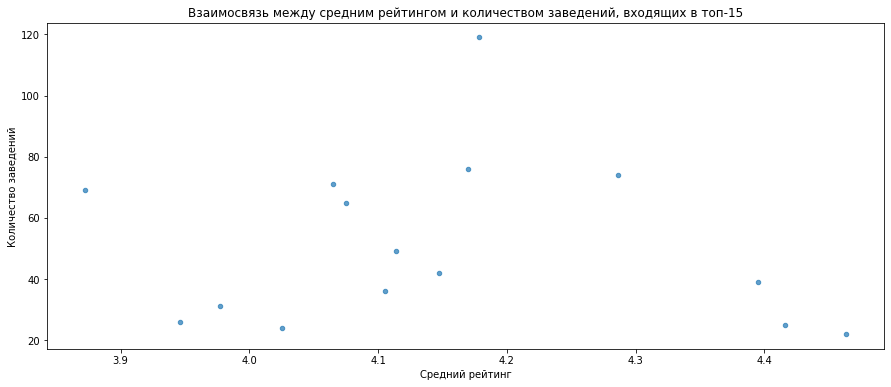

In [43]:
# Точечная диаграмма распределения сетевых заведений
df_chain_grouped.plot(
    kind = 'scatter',
    x = 'rating',
    y = 'id',
    marker = 'o',
    alpha = 0.7,
    figsize = (15, 6)
)
plt.title('Взаимосвязь между средним рейтингом и количеством заведений, входящих в топ-15')
plt.xlabel('Средний рейтинг')
plt.ylabel('Количество заведений')
plt.show()

**Выводы:** Самой популярной сетью заведений общепита в Москве является "Шоколадница", их по Москве 120. На втором и третьем местах расположились пиццерии "Домино'с Пицца" и "Додо Пицца", их количество составляет 76 и 74 заведения соответственно. Стоит отметить, что на четвертом месте расположилась кофейня "One price coffee" (71 заведение). Средний рейтинг всех этих заведений выше 4 баллов, что является хорошим показателем. Также в топ-5 вошла "Яндекс Лавка", их количество составляет 65, но ее средний рейтинг равен 3.87. Больше всего в топ-15 содержится кофеен (6 сетевых заведений), а вот меньше всего булочных (1 сетевое заведение). Но стоит отметить, что у нее достаточно высокий рейтинг - 4.42.  

---

### Задача 8

*Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.*


In [44]:
# Найдем среднее значение среднего чека заведения в разрезе округов Москвы
df_district = df.groupby('district').agg({'middle_avg_bill': ['mean', 'median']})
df_district.columns = ['mean', 'median']
df_district.sort_values(by = 'mean', ascending = False)

,mean,median
district,,
Центральный административный округ,1191.057547,1000.0
Западный административный округ,1053.225490,1000.0
Северный административный округ,927.959627,650.0
Южный административный округ,834.398089,500.0
Северо-Западный административный округ,822.222930,700.0
Восточный административный округ,820.626923,575.0
Юго-Западный административный округ,792.561702,600.0
Северо-Восточный административный округ,716.611296,500.0
Юго-Восточный административный округ,654.097938,450.0


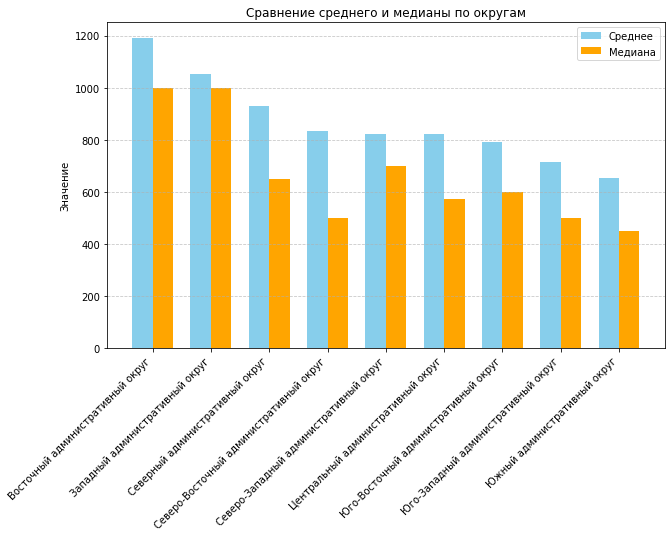

In [45]:
# Построение диаграммы
df_district_sorted = df_district.sort_values('mean', ascending = False)
fig, ax = plt.subplots(figsize = (10, 6))
# Параметры
bar_width = 0.35
index = range(len(df_district))
# Столбцы
bars1 = ax.bar(index, df_district_sorted['mean'], bar_width, label = 'Среднее', color = 'skyblue')
bars2 = ax.bar([i + bar_width for i in index], df_district_sorted['median'], bar_width, label = 'Медиана', color = 'orange')
# Настройка осей
ax.set_ylabel('Значение')
ax.set_title('Сравнение среднего и медианы по округам')
ax.set_xticks([i + bar_width / 2 for i in index])
ax.set_xticklabels(df_district.index, rotation = 45, ha = 'right')
# Легенда и сетка
ax.legend()
ax.grid(axis = 'y', linestyle = '--', alpha = 0.7)
# Показать график
plt.show()

**Выводы:** Центральный административный округ выделяется наиболее высокими значениями как среднего (1191.06), так медианного (1000.00) значений. Это говорит о том, что в нем в целом выше уровень среднего чека. Та же самая ситуация и с Западным административным округом, там среднее равно 1053.23, а медиана - 1000.00, и при этом следует отметить, что распределение относительно симметричное (среднее близко к медиане). В остальных округах значения среднего чека ниже, причем среднее заметно превышает медианное значением (особенно в Северо-Восточном и Юго-Восточном округах). Это может говорить нам о наличии правосторонней асимметрии, когда большиинство значений сосредоточено в нижней части диапазона, но есть высокие выбросы, которые тянут среднее вверх. Наименьшие показатели в Юго-Восточном административном округе, там среднее составляет 654,10, а медиана - 450.00. Это может указывать на более низкий общий уровень. В целом, наблюдается выраженная пространственная неравномерность - центр превосходит остальные округа, а разрыв между средним и медианой в периферийных округах говорит о неравномерном распределении внутри них. 

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

1. **Структура заведений:** Доминируют кафе (28%) и рестораны (24%), меньше всего - столовых и булочных (примерно 3% каждая).
2. **География:** Центральный округ - лидер по количеству заведений (27%), особенно ресторанов, Северо-Западный округ - аутсайдер (5%). 
3. **Сетевость:** Несетевых заведений больше, но в булочных, кофейнях и пиццериях - сетевые преобладают. 
4. **Посадочные места:** В выборке содержатся высокие выбросы (выборка от 0 до 1288 мест), при этом медиана составляет 75, а среднее - 108, следовательно, медиана надежнее для проведения анализа. 
5. **Рейтинг:** Высокий и стабильный - в среднем больше 4 баллов, без выраженных различий по категориям. 
6. **Корреляция:** Слабая связь рейтинга с ценой (0.22) и местоположением (0.20), выше цена - выше рейтинг. 
7. **Топ-сети:** "Шоколадница" (120 заведений), "Домино'с пицца" (76 заведений), "Додо пицца" (74 заведения). В топ-15 вошли в большинстве степени кофейни. 
8. **Чеки:** В Центральном и Западном округах самые высокие средние чеки (медиана равна 1000.00), в других округах средний чек ниже и данные имеют сильную ассиметрию. 

Центральный округ Москвы - центр притяжения заведений: больше заведений и выше средний чек. При этом в целом рынок общепита качественный, так как средний рейтинг больше 4 баллов. 

## 4. Итоговый вывод и рекомендации


### ***Общий обзор проделанной работы.***

В рамках исследовательского анализа были изучены данные о заведениях общественного питания Москвы: информация о типах заведений, их географическом распределении, сетевом/несетевом статусе, вместимости, рейтингах, ценовых категориях и среднем чеке. Исходные данные включали два датафрейма (всего ~8,4 тыс. заведений), содержащих как базовую информацию (название, категория, округ, сетевой статус), так и показатели, связанные с клиентским опытом и ценообразованием (рейтинг, средний чек, вместимость).

Было принято обоснованное решение не удалять и не импутировать пропуски, поскольку они составляли более 50% по ключевым финансовым и операционным метрикам (средний чек, цена, вместимость). Это позволило избежать искажения результатов анализа, особенно в части сравнения сетевых и несетевых заведений.

Проведена предобработка: проверка типов данных, анализ дубликатов, создание производного признака `is_24_7` (круглосуточная работа), а также комплексный исследовательский анализ - от описательной статистики до корреляционных зависимостей и сравнения по категориям и районам.

### ***Главные выводы по исследовательским вопросам.***

**Структура рынка:**
- Преобладают *кафе* (28.3%) и *рестораны* (24.3%) - более половины всех заведений.
- *Кофейни* занимают третье место (16.8%), несмотря на меньшее количество, они активно представлены в топе сетей.
- *Булочные и столовые* - наименее распространены (3–3.8%), но имеют высокие рейтинги (например, булочная сеть - 4.42).
- *Центральный АО* - лидер по концентрации заведений (26.7%), особенно ресторанов и кафе.

**Сетевой vs несетевой сегмент:**
- Несетевые заведения преобладают в абсолютном числе, но *сетевые доминируют в категориях с высоким потенциалом масштабирования*: кофейни, булочные, пиццерии.
- *Топ-3 сети*: Шоколадница (120 точек), Домино'с (76) и Додо Пицца (74) - все с рейтингом больше 4.
- Яндекс Лавка (65 точек) выбивается по рейтингу (3.7), что может сигнализировать о специфике формата.

**Операционные характеристики:**
- *Вместимость*: медиана - 75 мест, среднее - ~108 (с сильным влиянием выбросов).
        - Рестораны, бары и кофейни - более вместительные (медиана больше или равна 80).
        - Наличие значений 0 и 1288 мест указывает на разнородность форматов (фудтраки, фудкорт-участники).
- *Рейтинг*: стабильно высокий - в среднем *больше 4 из 5* по всем категориям, без выраженных различий между типами заведений.

**Ценообразование и локация:**
- *Цена и рейтинг слабо, но положительно коррелируют* (r = 0.22): более дорогие заведения получают чуть более высокие оценки - вероятно, за счёт качества, сервиса и атмосферы.
- *Пространственное неравенство*:
        - В Центральном АО средний чек - 1191 руб., медиана - 1000 руб. (равномерное, высокое распределение).
        - В периферийных округах (особенно ЮВАО) средний чек - 654 руб., медиана - 450 руб., что указывает на сильную правостороннюю асимметрию: большинство заведений - бюджетные, но есть отдельные премиальные точки.
        
### ***Рекомендации на основе анализа.***

**1. Для развития новых точек / входа на рынок**
- *Фокус на Центральный и Западный АО* - там выше платежеспособность и стабильный спрос на средний и выше чек.
- *Перспективные ниши для сетей*:
        - Кофейни - высокая плотность сетей + устойчивый спрос; потенциал в форматах «быстрого кофе» (например, One price coffee).
        - Булочные - низкая насыщенность рынка, но высокий клиентский отклик (рейтинги до 4.42). Возможность позиционирования как «премиум-выпечка».
- Избегать «гиперконкуренции» в сегменте кафе и ресторанов без чёткого УТП.


**2. Для оптимизации существующих сетей**
- *Дифференциация по формату*:
        - Для высокорейтинговых сетей (Шоколадница, Додо) - укреплять позиции в центре и развивать премиальные локации.
        - Для сетей с пониженным рейтингом (Яндекс Лавка) - анализ причин, возможно, введение «точек присутствия» с зоной ожидания/кофе-баром для повышения вовлечённости.
- *Анализ вместимости*:
        - Для заведений с 0 мест - формализовать описание как «вынос/доставка» в карточке.
        - Для точек с аномально высокой вместимостью (больше 500) - проверить корректность данных (возможно, это фудкорты, а не отдельные заведения).


**3. Для маркетинга и позиционирования**
- *Акцент на цене-качество-рейтинг*: даже в бюджетном сегменте можно добиться высоких оценок - клиенты ценят чистоту, скорость и дружелюбие.
- *Гео-таргетированная коммуникация*:
        - В центре - делать упор на атмосферу, эксклюзивность, локальный колорит.
        - На окраинах - выгодные комплекты, семейные предложения, лояльность (бонусы за повторные визиты).


**4. Для будущих исследований**
- *Сбор дополнительных данных по*:
        - графикам загрузки (часы пик),
        - составу меню (соотношение вегетарианских/постных/детских блюд),
        - отзывам (тональный анализ),
        - динамике рейтингов во времени.
- Возможна *сегментация по «скрытым» группам* (например, через кластерный анализ на основе: рейтинг + цена + вместимость + округ), что позволит выявить «типовую точку успеха».

***В заключение:*** рынок общественного питания в Москве характеризуется *высокой конкуренцией в массовом сегменте, но остаётся потенциал для роста в узких нишах и на периферии* - при условии адаптации формата под локальные особенности и грамотного позиционирования. Главный актив - стабильно *высокая удовлетворённость клиентов*, которую важно не только сохранять, но и конвертировать в лояльность и повторные визиты.